<h1><font color="#4472c4">MSBA 511: Data Mining for Business Analytics</font></h1>

## Programming Assignment 3: Decision Trees

In this assignment, you will be working with a small coffee dataset for a popular specialty coffee company, Torero Specialty Coffee (TSC), that sells:

- specialty coffee beans, in bulk (by the kilogram only) 
- coffee equipment and merchandise (grinders, brewing equipment, mugs, books, t-shirts).

TSC operates three stores, two in Europe and one in the USA. The flagshap store is in the USA, and everything is quality assessed there, before being shipped out. TSC typically buys coffee from farmers, processes it on site, brings it back to the USA, roasts it, packages it, markets it, and ships it (only in bulk, and after quality assurance) to customers internationally. These customers all own coffee shops in major cities like New York, Paris, London, Hong Kong, Tokyo, and Berlin. 

TSC is faced with a decision about whether to strike a deal with a legendary coffee farm (known as the **Hidden Farm**) in rural China. It is a risky decision, as the deal will be expensive, and the coffee might not be bought by customers. TSC conducted a survey of 710 of its most loyal customers and collected the following information:
- age
- gender 
- salary 
- whether they have bought at least one product online
- their distance from the flagship store in the USA (standardized to a number between 0 and 11) 
- how much they spent on TSC products on the week of the survey 
- how much they spent on TSC products in the month preeding the survey
- the number of TSC bean shipments each customer has ordered over the preceding year

Finally, each customer participating in the survey was asked whether they would buy the Hidden Farm coffee, and some (but not all) of the customers responded to that question. If TSC can estimate an interest level of at least **70%** of its most popular customers to buy the Hidden Farm coffee, TSC strike the deal with Hidden Farm farmers and sell the coffee. A decision tree will be used to predict the buy interest of all of the customers that did not respond to the question to help with the decision. 

**Credit**: This assignment is a modified version of the Supervised Learning assignment in Springboard's Data Science Career Track course. 

#### Import libraries

Set `SEED = 23` for expected output reproducability.

In [1]:
# Set random seed
SEED = 23

## Step 1: Load and Prepare Data

**Load data from csv file and display first 5 rows.**

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Expected Output: </h3>

,Age,Gender,num_coffeeBags_per_year,spent_week,spent_month,SlrAY,Distance,Online,Decision
0,36,Female,0,24,73,42789,0.003168,0,1.0
1,24,Male,0,44,164,74035,0.520906,0,NaN
2,24,Male,0,39,119,30563,0.916005,1,1.0
3,20,Male,0,30,107,13166,0.932098,1,NaN
4,24,Female,0,20,36,14244,0.965881,0,1.0


**Rename the following columns only to words which maximize meaning and clarity:**

- spent_week: `spent_last_week`
- spent_month: `spent_last_month`
- SlrAY: `salary`

**Let's also convert all columns to _lower_case_ for consistency.**
  
Display the first 5 rows again.

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Expected Output: </h3>

,age,gender,num_coffeebags_per_year,spent_last_week,spent_last_month,salary,distance,online,decision
0,36,Female,0,24,73,42789,0.003168,0,1.0
1,24,Male,0,44,164,74035,0.520906,0,NaN
2,24,Male,0,39,119,30563,0.916005,1,1.0
3,20,Male,0,30,107,13166,0.932098,1,NaN
4,24,Female,0,20,36,14244,0.965881,0,1.0


Explore the **data types** of all variables, the **number of non-null values**, and how much **memory** is being used to store the data using the `.info()` method.

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Expected Output: </h3>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 702 entries, 0 to 701
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      702 non-null    int64  
 1   gender                   702 non-null    object 
 2   num_coffeebags_per_year  702 non-null    int64  
 3   spent_last_week          702 non-null    int64  
 4   spent_last_month         702 non-null    int64  
 5   salary                   702 non-null    int64  
 6   distance                 702 non-null    float64
 7   online                   702 non-null    int64  
 8   decision                 474 non-null    float64
dtypes: float64(2), int64(6), object(1)
memory usage: 49.5+ KB


Generate descriptive statistics for the data for **numeric** and **object** columns.

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Expected Output: </h3>

,age,num_coffeebags_per_year,spent_last_week,spent_last_month,salary,distance,online,decision
count,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000,474.000000
mean,34.243590,2.710826,32.853276,107.923077,43819.843305,4.559186,0.531339,0.639241
std,13.927945,1.593629,15.731878,55.348485,26192.626943,3.116275,0.499373,0.480728
min,16.000000,0.000000,0.000000,0.000000,1617.000000,0.003168,0.000000,0.000000
25%,23.000000,1.000000,24.250000,62.000000,22812.250000,1.877812,0.000000,0.000000
50%,28.000000,3.000000,36.000000,113.500000,41975.000000,4.196167,1.000000,1.000000
75%,46.000000,4.000000,43.000000,150.750000,60223.000000,6.712022,1.000000,1.000000
max,90.000000,5.000000,62.000000,210.000000,182058.000000,10.986203,1.000000,1.000000


ℹ️**Only 63.92% of the customers that participated in the survey indicated they would buy the Hidden Farm coffee so the prelimary decision is to not strike a deal with Hidden Farm coffee.**

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Expected Output: </h3>

,gender
count,702
unique,9
top,Male
freq,355


**Some datasets don't require any cleaning, but almost all do. Clean the Gender column and replace the inconsistent values to align with the top value for each.**

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:red"> No Expected Output for this Step </h3>

gender
Male      358
Female    344
Name: count, dtype: int64

**Create a dummy variable for the `gender` column.**

Be sure to remove the first value in the level and do not include the `gender` object column in the new output.

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Expected Output: </h3>

,age,num_coffeebags_per_year,spent_last_week,spent_last_month,salary,distance,online,decision,gender_Male
0,36,0,24,73,42789,0.003168,0,1.0,False
1,24,0,44,164,74035,0.520906,0,NaN,True
2,24,0,39,119,30563,0.916005,1,1.0,True
3,20,0,30,107,13166,0.932098,1,NaN,True
4,24,0,20,36,14244,0.965881,0,1.0,False


**Let's now separate the dataset based on the null values in the `decision` column.**

- Create a new dataframe that contains all customers that answered the question about purchasing the coffee.
- Create another dataframe that contains all customers that did **NOT** answer the question about purchasing the coffee. These are the customers we will need to make a prediction for.

**Display the shape of each dataframe.**

ℹ️ Reviewing the shape ensures that both datasets start out consistent for training and predictions.

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Expected Output: </h3>

Coffee Data with Decision: (474, 9)


<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Expected Output: </h3>

Coffee Data that will Require Predictions: (228, 9)


## Step 2: Conduct Exploratory Analysis

Conducting **exploratory data analysis (EDA)** before modeling is important because it helps uncover patterns, detect potential anomalies, and ensure data quality, leading to more reliable models. Simply throwing all variables into a model without understanding the data can result in misleading conclusions, overfitting, or poor model performance due to issues like multicollinearity, missing values, or irrelevant features. EDA allows analysts to visualize distributions, assess relationships, and refine feature selection, ultimately improving model interpretability and effectiveness.

**Create a 2 x 3 grid of Box Plots for the following variables:**

- `age`
- `num_coffeebags_per_year`
- `spent_last_week`
- `spent_last_month`
- `salary`
- `distance`

**We want to visualize the distribution of each variable segmented by the `decision` column so `decision` should be on the x-axis.**

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Expected Output: </h3>

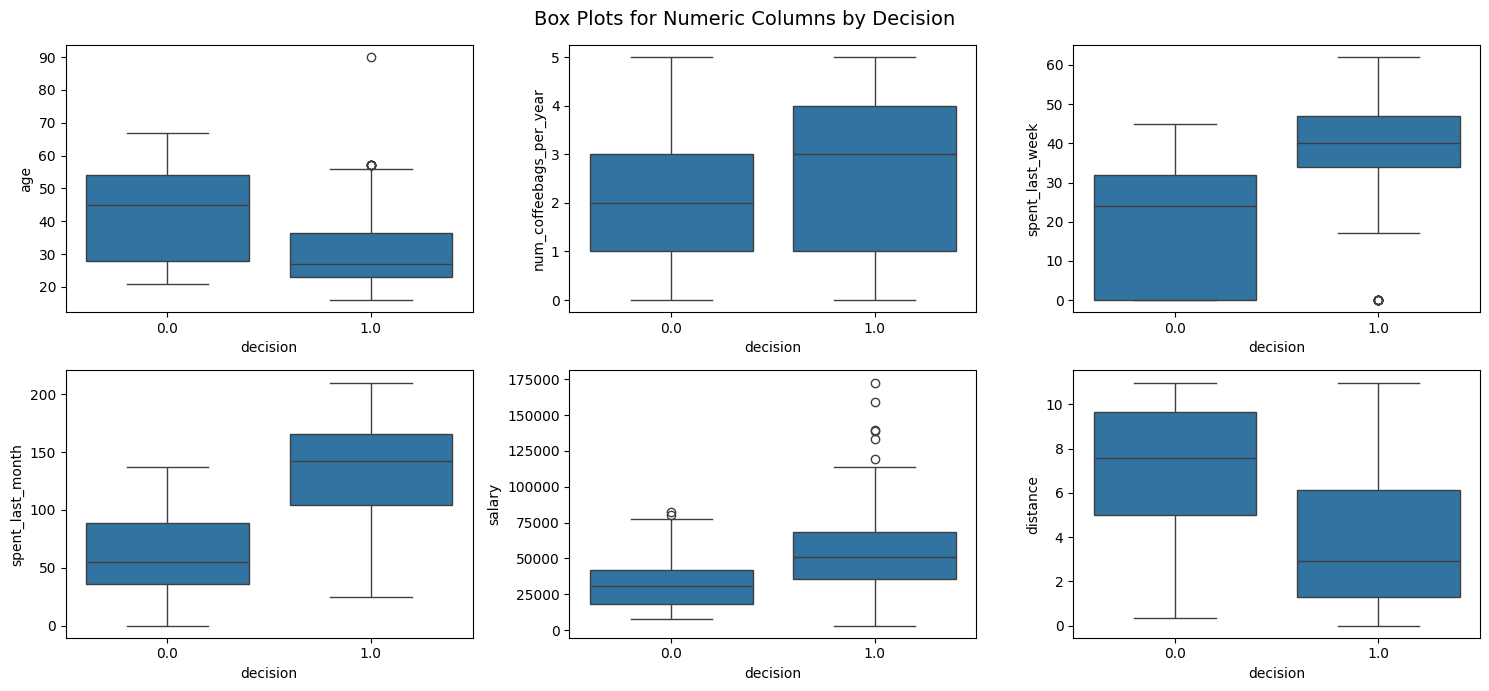

**What insights can you draw from the distribution of values by the `decision` column?**

<h4 style="color:purple"> Write Your Free-Form Response Below: </h4>

**Create a correlation heatmap for all numeric columns.**

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Expected Output: </h3>

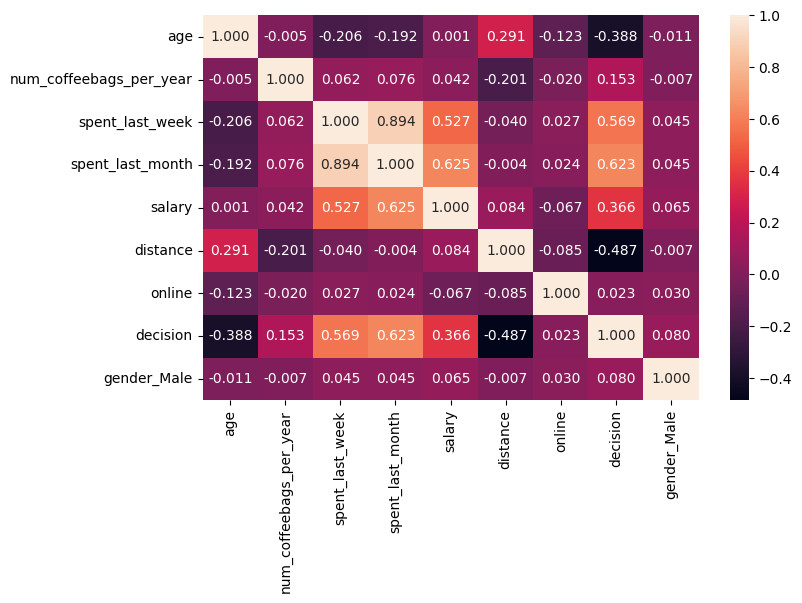

**Create a bar chart for the correlation values for the `decision` column only.**

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Expected Output: </h3>

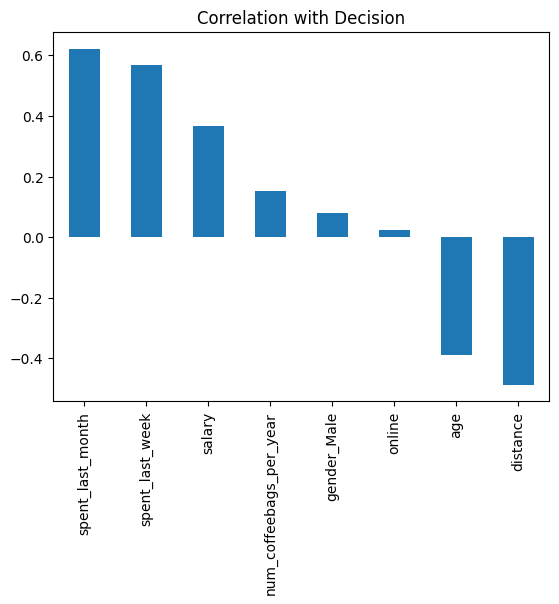

**What insights can you draw from the correlation analysis?**

ℹ️ Any columns we could reasonably exclude from modeling at this stage?

<h4 style="color:purple"> Write Your Free-Form Response Below: </h4>

## Step 3: Preprocessing and Modeling

**Create an independent variables DataFrame X with the columns identified in EDA and dependent variable Series y with the `decision` column.**

**Display the shape of the train and test partitions.**

⚠️ Split the data and set aside **25%** of the data for test partition. Reminder to use the `SEED` set previously for `random_state`.⚠️ 

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Sample Output: </h3>

X_train shape: (355, 7)
y_train shape: (355,)
X_test shape: (119, 7)
y_test shape: (119,)


### Step 3a: Evaluate Different Models

**Create a Decision Tree Classifier with no limit on tree growth using the `entropy` splitting criteria.**

⚠️ Reminder to use the `SEED` set previously for `random_state` and make predictions on `X_test` so you can evaluate the model in the next step.⚠️ 

ℹ️ **sklearn will not display parameters in the output object if they are the same as the default option.**

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Expected Output: </h3>

DecisionTreeClassifier(criterion='entropy', random_state=23)

**Plot the Decision Tree.**

ℹ️**Over the next few steps, you will be asked to conduct similar tasks with just some inputs changed. You might find it beneficial to utilize Python functions.** 

⚠️You are **NOT** expected to match the aesthetics of the sample output. Feel free to use any tree plotting method.⚠️

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Sample Output: </h3>

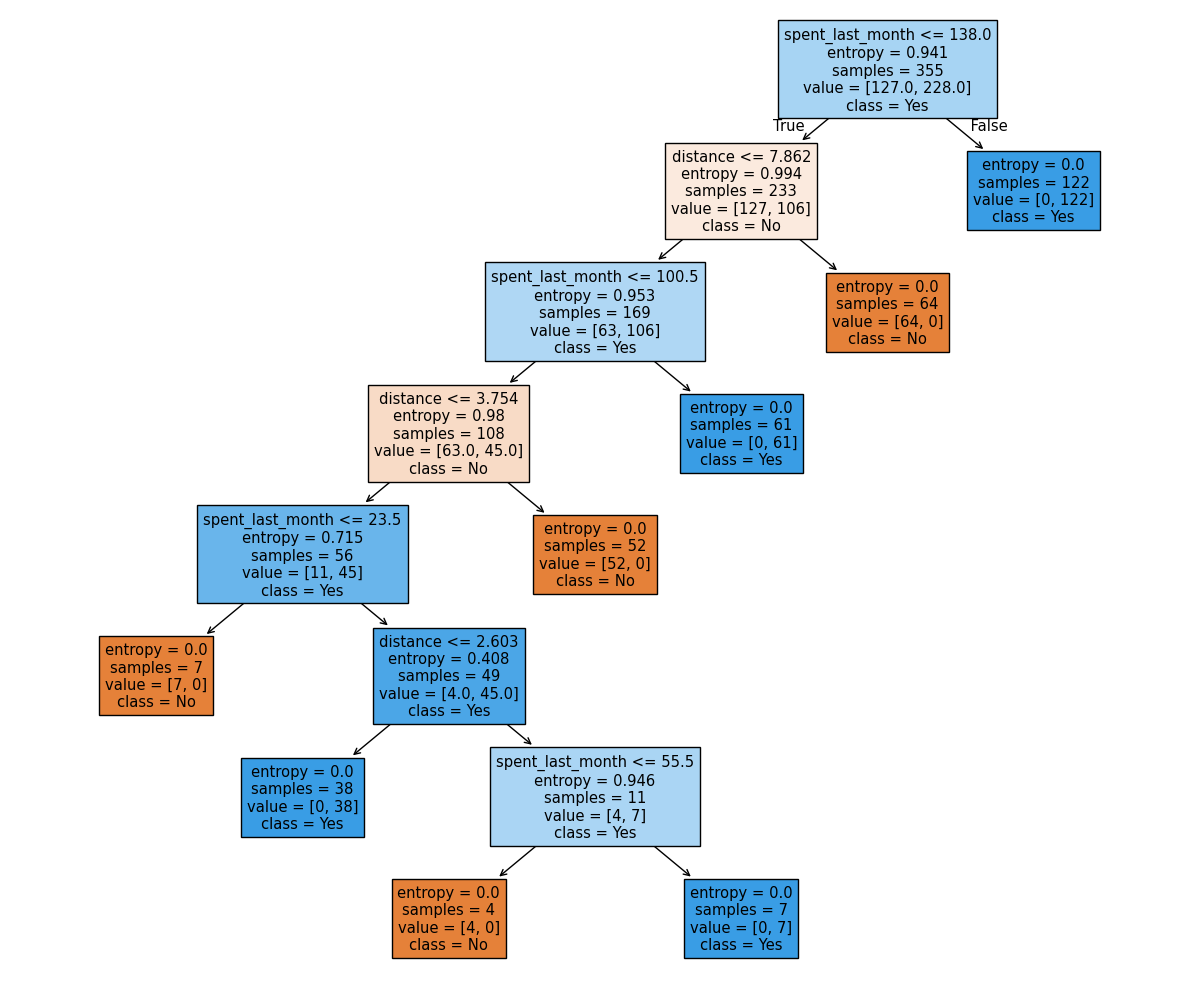

**Display evaluation metrics.**

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Sample Output: </h3>

Decision Tree 1: Entropy - No max depth
Accuracy: 0.9747899159663865
Precision score for "Yes" 0.9864864864864865
Precision score for "No" 0.9555555555555556
Recall score for "Yes" 0.9733333333333334
Recall score for "No" 0.9772727272727273


**Plot Confusion Matrix.**

⚠️You are **NOT** expected to match the aesthetics of the sample output. Feel free to use any confusion matrix method.⚠️

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Sample Output: </h3>

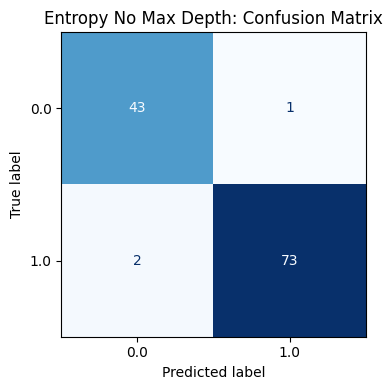

**Create a Decision Tree Classifier with no limit on tree growth using the `gini` splitting criteria.**

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Expected Output: </h3>

DecisionTreeClassifier(random_state=23)

**Plot the Decision Tree.**

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Sample Output: </h3>

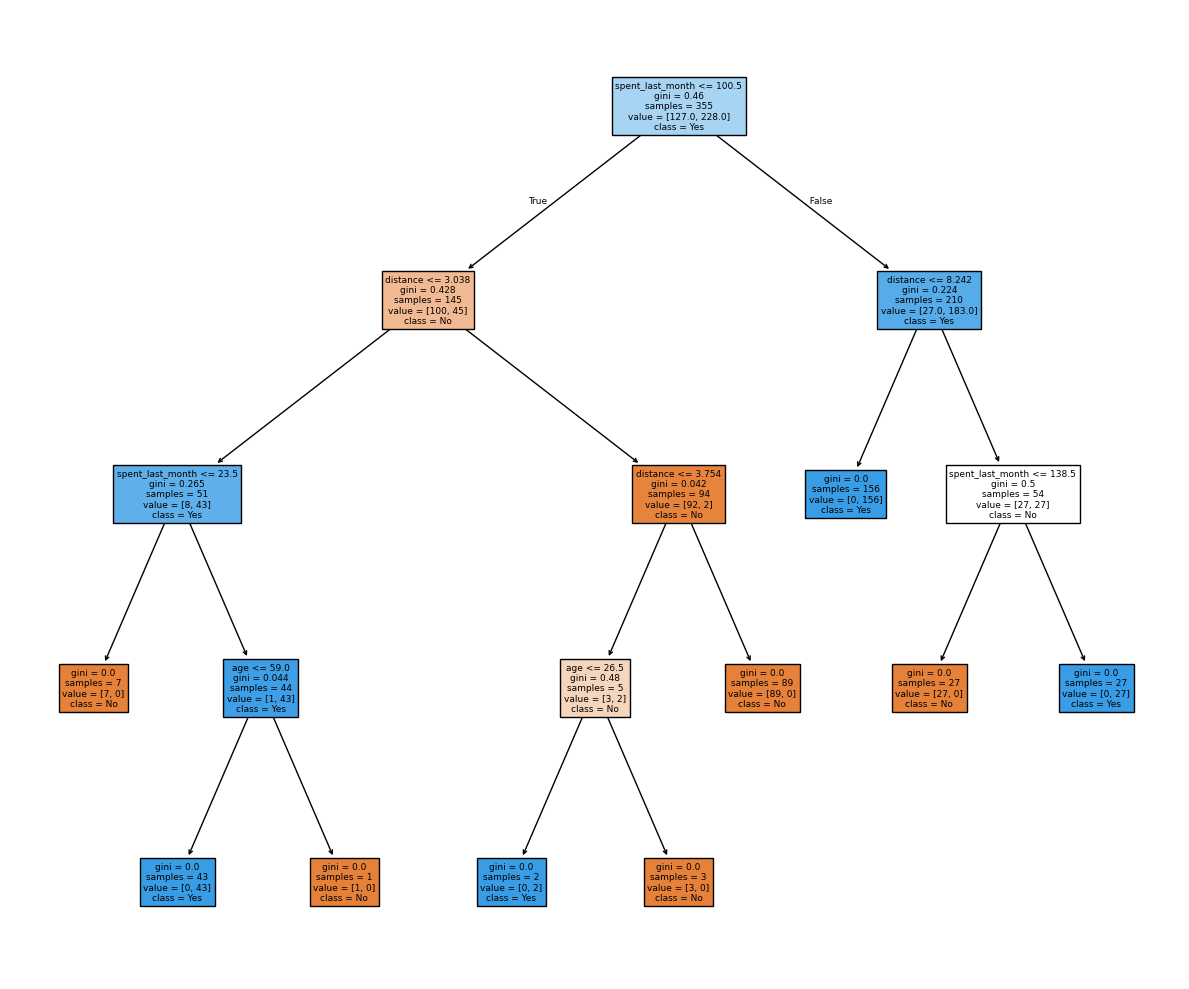

**Display evaluation metrics.**

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Sample Output: </h3>

Decision Tree 2: Gini - No max depth
Accuracy: 0.9831932773109243
Precision score for "Yes" 0.9866666666666667
Precision score for "No" 0.9772727272727273
Recall score for "Yes" 0.9866666666666667
Recall score for "No" 0.9772727272727273


**Plot Confusion Matrix.**

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Sample Output: </h3>

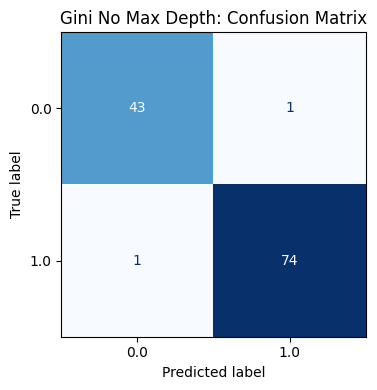

**How do the results here compare to the previous model? Write your insights here.**

<h4 style="color:purple"> Write Your Free-Form Response Below: </h4>

### Step 3b: Identify Optimal Parameters

**Run an exhaustive search using `sklearn.model_selection.GridSearchCV` to identify the best parameters for:**

- criterion
- max_depth
- min_samples_leaf

Experiment with the different range of options for each parameter. Use a **5 k-fold cross validation** strategy and **precision** scoring. Display the best parameters and score.

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Sample Output: </h3>

Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 3}
Best Score: 0.9774647887323944


**Create a Decision Tree Classifier with best parameters.**

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Sample Output: </h3>

DecisionTreeClassifier(max_depth=5, min_samples_leaf=3, random_state=23)

**Plot the Decision Tree.**

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Sample Output: </h3>

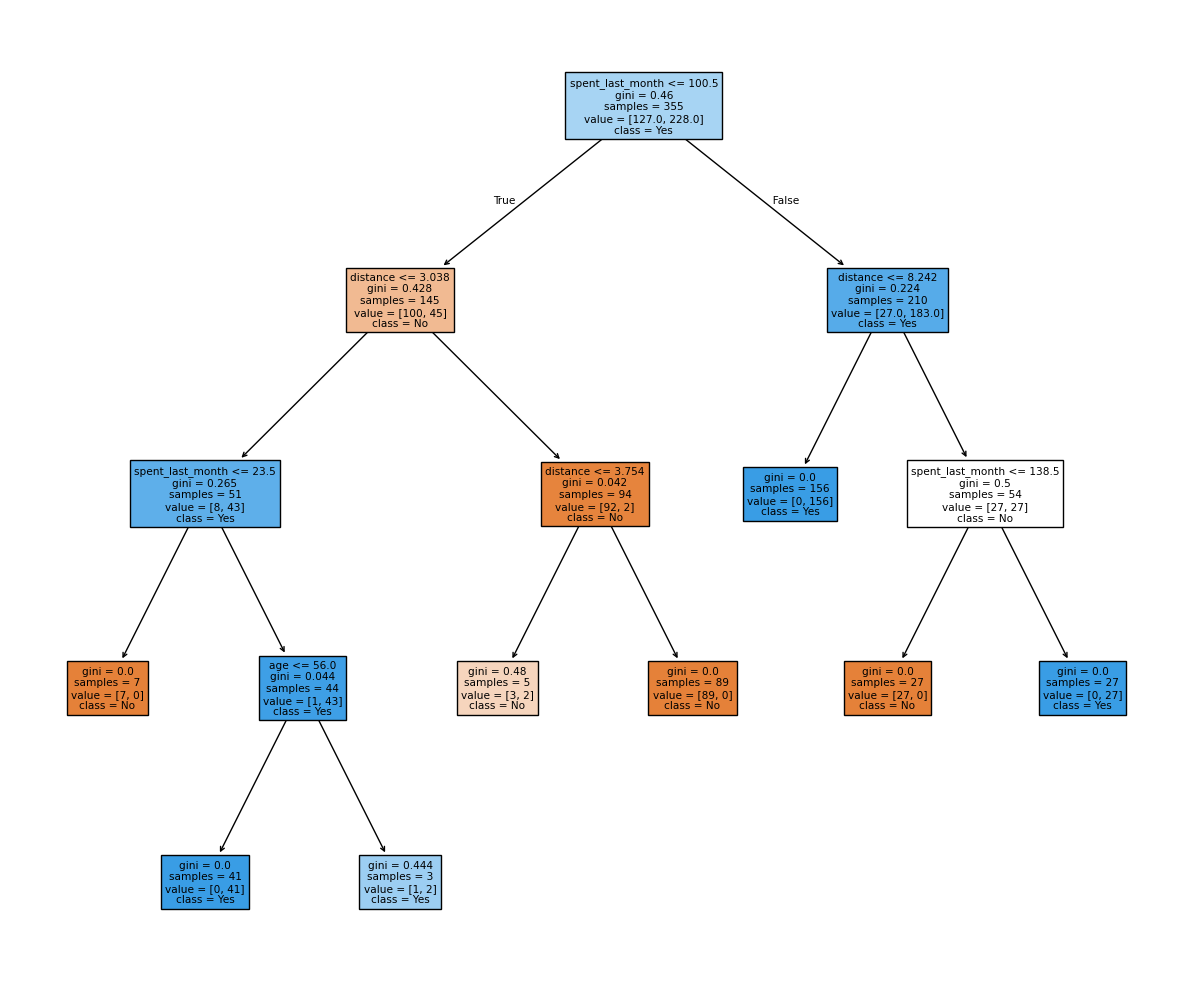

**Display evaluation metrics.**

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Sample Output: </h3>

Decision Tree 3: Best Params
Accuracy: 0.9831932773109243
Precision score for "Yes" 0.9866666666666667
Precision score for "No" 0.9772727272727273
Recall score for "Yes" 0.9866666666666667
Recall score for "No" 0.9772727272727273


**Plot Confusion Matrix.**

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Sample Output: </h3>

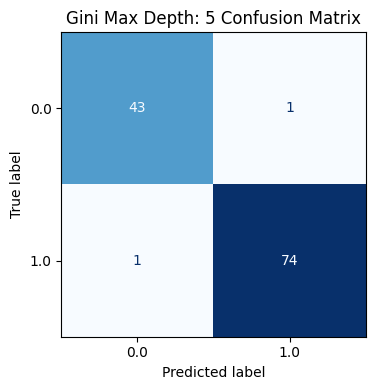

## Step 4: Final Conclusion

Now you will use your best model to make predictions on the customers that did not respond to the question in the survey. Merge the predictions so we have a value for the `decision` column for all **702** customers. Based on the original threshold of **70%**, do you recommend TSC strike the deal with Hidden Farm farmers and sell the coffee?

⚠️ In this step, we only provide an example output with no numbers. ⚠️

**Replace the ##.##% with your final `decision` percentage.**

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Example Output: </h3>

##.##% of people want to buy the Hidden Farm coffee.


**Make your recommendation for TSC and discuss any potential limitations of your analysis.**

For example, we have a small sample size of customers that were surveyed. Do you get a different decision tree classifier and result if you we use a different random split of the train and test partitions?

<h4 style="color:purple"> Write Your Free-Form Response Below: </h4>